In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Goals of scoping in a deep research agent

1. **User Clarification** - Determines if additional clarification is needed from the user
2. **Brief Generation** - Transforms the conversation into a detailed research brief

Output: A clear brief which can be used by other processes (like detailed research section)

**Need for scoping**: User requests often lack important details like:

- **Scope and boundaries**: What should be included or excluded?
- **Audience and purpose**: Who is this research for and why?
- **Specific requirements**: Are there particular sources, timeframes, or constraints?
- **Clarification of terms**: What do domain-specific terms or acronyms mean?
- Rather than making assumptions, we gather additional context through targeted clarification questions.

## Scope Agent Setup

In [2]:
# Custom imports
from src.agent_prompts import (
    clarify_with_user_instructions,
    transform_messages_into_research_topic_prompt,
    revise_research_brief_prompt,
)

### State and Schemas
 
> **Note:** Use `%%writefile` to **save the code block** to a specific file when it runs. We will use it to create a python code that can used directly in a deployable LangGraph application for detailed analysis (in [./src/](./src/) directory)

In [3]:
# %%writefile ./src/state_scope.py

import operator
from typing import Optional, Annotated, List, Sequence
from pydantic import BaseModel, Field

from langchain_core.messages import BaseMessage
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages

######### STATE DEFINITIONS #########

class AgentInputState(MessagesState):
    """Input state for the full agent - only contains messages from user input.""" # empty for now, since this code is just for scoping part of the full agent.
    pass

class AgentState(MessagesState):
    """
    Main state for the full multi-agent research system.
    
    Extends MessagesState with additional fields for research coordination.
    Note: Some fields are duplicated across different state classes for proper
    state management between subgraphs and the main workflow.
    """
    research_brief: Optional[str] # Research brief generated from user conversation history
    reviewer_feedback: Optional[str] # Set by human_review_brief on rejection; consumed and cleared by write_research_brief on the next pass
    supervisor_messages: Annotated[Sequence[BaseMessage], add_messages] # Messages exchanged with the supervisor agent for coordination
    raw_notes: Annotated[list[str], operator.add] # Raw unprocessed research notes collected during the research phase
    notes: Annotated[list[str], operator.add] # Processed and structured notes ready for report generation
    final_report: str # Final formatted research report


######### STRUCTURED OUTPUT DEFINITIONS #########

class ClarifyUserRequest(BaseModel):
    """Structured output for requesting clarification from the user."""
    need_clarification: Annotated[bool, Field(..., description="Indicates whether clarification is needed from the user.")] # `...` indicates this field is required. Use `None` for optional fields.
    question_to_user: Annotated[str, Field(default="", description="The question to ask the user for clarification. Required only when need_clarification=True; otherwise empty string.")]
    verification: Annotated[str, Field(default="", description="Acknowledgment message confirming the user's request is sufficient to proceed with research. Required only when need_clarification=False; otherwise empty string.")]

class ResearchBrief(BaseModel):
    """Structured output for the research brief generated from user input."""
    research_brief: Annotated[str, Field(..., description="A concise research brief summarizing the user's request and the research objectives to guide the research agents.")]

### Scope Research

We'll create a simple workflow to clarify user intent and determine whether it has sufficient clarification to write the brief.
 
This will use LangGraph's [Command](https://langchain-ai.github.io/langgraph/how-tos/graph-api/#combine-control-flow-and-state-updates-with-command) to direct the control flow and updating state. The `Command` object takes two key parameters:
- `goto`: Specifies the next node to execute (or `END` to terminate)
- `update`: Dictionary of state updates to apply before transitioning

This pattern allows our functions to both process data and direct the workflow based on their results. 

It creates a more flexible and maintainable system than traditional static graph structures.

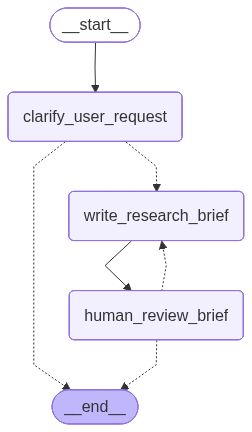

In [4]:
# %%writefile ./src/research_agent_scope.py

"""User Clarification, Research Brief Generation, and Human Review.

This module implements the scoping phase of the research workflow, where we:
1. Assess if the user's request needs clarification
2. Generate a detailed research brief from the conversation
3. Pause for a human reviewer to either approve the brief or request refinements

The workflow uses structured output to make deterministic decisions about
whether sufficient context exists to proceed with research, and a dynamic
`interrupt()` to gate the brief on human approval before downstream agents
consume it.
"""

from datetime import datetime
from typing_extensions import Literal

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

# custom imports
from src.agent_prompts import (
    clarify_with_user_instructions,
    transform_messages_into_research_topic_prompt,
    revise_research_brief_prompt,
)
from src.utils import date_today_str

model = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)

############### NODE FUNCTIONS ###############

def clarify_user_request(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research.
    
    Uses structured output to make deterministic decisions and avoid hallucination.
    Routes to either research brief generation or ends with a clarification question.
    """
    clarify_model = model.with_structured_output(ClarifyUserRequest)

    clarification_prompt = clarify_with_user_instructions.format(
        messages=get_buffer_string(messages=state["messages"]), 
        date=date_today_str()
    )

    response = clarify_model.invoke([HumanMessage(content=clarification_prompt)])


    # Based on the structured output, decide whether to proceed to research brief generation or ask for clarification
    if response.need_clarification:
        return Command(
            goto=END,
            update={
                "messages": [AIMessage(content=response.question_to_user)]
            }
        )
    else:
        return Command(
            goto="write_research_brief",
            update={
                "messages": [AIMessage(content=response.verification)],
            }
        )


def write_research_brief(state: AgentState):
    """
    Generate or revise the research brief.

    Dual-mode: if `reviewer_feedback` is present in state alongside an existing
    `research_brief`, tweak the prior brief using the revise prompt instead of
    regenerating from the full conversation. Otherwise, run the original
    transform-from-messages flow. Feedback is consumed and cleared in the same
    return so the loop resets cleanly on the next human review.
    """
    research_brief_model = model.with_structured_output(ResearchBrief)

    feedback = state.get("reviewer_feedback")
    previous_brief = state.get("research_brief")

    if feedback and previous_brief: # if human reviewer has provided feedback and there's an existing brief to revise, use the revision prompt
        prompt = revise_research_brief_prompt.format(
            previous_brief=previous_brief,
            reviewer_feedback=feedback,
            date=date_today_str(),
        )
    else: # otherwise, generate a new research brief from the conversation history using the original prompt
        prompt = transform_messages_into_research_topic_prompt.format(
            messages=get_buffer_string(state.get("messages", [])),
            date=date_today_str(),
        )

    response = research_brief_model.invoke([HumanMessage(content=prompt)])

    return {
        "research_brief": response.research_brief,
        "supervisor_messages": [HumanMessage(content=f"{response.research_brief}")],
        "reviewer_feedback": None,  # consume and clear so the loop resets
    }


def human_review_brief(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Pause for a human reviewer. Approve to proceed; reject with feedback to loop
    back to `write_research_brief` for a targeted revision.

    Resume payload contract:
        Command(resume={"approved": True}) -> graph proceeds to END.
        Command(resume={"approved": False, "feedback": "<text>"}) -> stores
        feedback in state and re-enters write_research_brief in revise mode.
    """
    review = interrupt({
        "type": "brief_review",
        "research_brief": state["research_brief"],
        "instructions": "Approve to proceed, or provide recommendations to refine the brief.",
    })

    if review.get("approved"):
        return Command(goto=END)

    feedback = review.get("feedback") or "Please refine the brief."
    return Command(
        goto="write_research_brief",
        update={"reviewer_feedback": feedback},
    )

# sample invocation for interrupt - shown for understanding only - do not run here
# graph.invoke(Command(resume={"approved": True}), config)
# or
# graph.invoke(Command(resume={"approved": False, "feedback": "tighten scope"}), config)


############### GRAPH CONSTRUCTION ###############

deep_research_builder = StateGraph(AgentState, input_schema=AgentInputState)

deep_research_builder.add_node("clarify_user_request", clarify_user_request)
deep_research_builder.add_node("write_research_brief", write_research_brief)
deep_research_builder.add_node("human_review_brief", human_review_brief)

deep_research_builder.add_edge(START, "clarify_user_request")
deep_research_builder.add_edge("write_research_brief", "human_review_brief")

from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
scope_flow = deep_research_builder.compile(checkpointer=memory)
display(Image(scope_flow.get_graph(xray=True).draw_mermaid_png()))

## Testing

User request: **Vague question**

In [5]:
from src.utils import format_messages

thread = {"configurable": {"thread_id": "a"}}
test_response = scope_flow.invoke(
    {
        "messages": [
            HumanMessage(content="Agentic AI best practices")
        ]
    },
    config=thread
)
format_messages(test_response["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Agentic AI best practices                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ To help me tailor the report on **Agentic AI best practices**, could you clarify a few things:                  │
│                                                                                                                 │
│ 1. **Audience & Purpose** – Who is this report for? (e.g., developers/engineers, business leaders, security     │
│ teams, general audience)                                                                                        │
│ 2. **Focus Area** – Are you interested in a specific aspect of agentic AI best practices, such as:              │
│    - System design & architecture                                                                               │
│    - Safety, alignment & guardrails                                                                             │
│    - Security & risk management                                                                                 │
│    - Deployment & operations                                                                                    │
│    - Governance & ethics                                                                                        │
│    - All of the above                                                                                           │
│ 3. **Scope** – Should this cover a specific industry or use case (e.g., enterprise software, healthcare,        │
│ finance), or remain general?                                                                                    │
│ 4. **Depth** – Do you prefer a high-level overview or a deep-dive technical report?                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Check LangSmith tracing [here](https://smith.langchain.com/public/4cea316a-a85f-4445-b98a-1d2bc8b8ebe0/r)

**Clarify AI**

In [6]:
result = scope_flow.invoke({"messages": [HumanMessage(content="I'm learning for production best practices in all those areas.")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Agentic AI best practices                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ To help me tailor the report on **Agentic AI best practices**, could you clarify a few things:                  │
│                                                                                                                 │
│ 1. **Audience & Purpose** – Who is this report for? (e.g., developers/engineers, business leaders, security     │
│ teams, general audience)                                                                                        │
│ 2. **Focus Area** – Are you interested in a specific aspect of agentic AI best practices, such as:              │
│    - System design & architecture                                                                               │
│    - Safety, alignment & guardrails                                                                             │
│    - Security & risk management                                                                                 │
│    - Deployment & operations                                                                                    │
│    - Governance & ethics                                                                                        │
│    - All of the above                                                                                           │
│ 3. **Scope** – Should this cover a specific industry or use case (e.g., enterprise software, healthcare,        │
│ finance), or remain general?                                                                                    │
│ 4. **Depth** – Do you prefer a high-level overview or a deep-dive technical report?                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'm learning for production best practices in all those areas.                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Great, I have enough information to proceed. I'll research a comprehensive report on **Agentic AI best          │
│ practices for production**, covering all key areas including system design & architecture, safety & guardrails, │
│ security & risk management, deployment & operations, and governance & ethics. The report will be tailored for a │
│ learning audience focused on real-world production implementation. Starting research now.                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Check LangSmith Tracing [here](https://smith.langchain.com/public/a98217ef-81d2-40e0-a2cd-3300c75f824b/r)

**Check the research brief which would be passed to the next step**

In [7]:
from rich.markdown import Markdown
Markdown(result["research_brief"])

I am learning about best practices for deploying and operating Agentic AI systems in production environments. I    
need a comprehensive report covering all of the following areas:                                                   

 1 System Design & Architecture – Best practices for designing agentic AI systems (e.g., agent orchestration,      
   multi-agent frameworks, tool use, memory management, context window management, modularity, and scalability for 
   production workloads).                                                                                          
 2 Safety, Alignment & Guardrails – How to implement guardrails, constrain agent behavior, prevent unintended      
   actions, ensure alignment with intended goals, and handle failure modes gracefully in production.               
 3 Security & Risk Management – Best practices for securing agentic AI systems against prompt injection, data      
   leakage, unauthorized actions, supply chain risks, and other threat vectors specific to autonomous agents       
   operating in production.                                                                                        
 4 Deployment & Operations – Production deployment strategies, monitoring, observability, logging, tracing agent   
   actions, debugging, performance optimization, cost management, and maintaining reliability of agentic systems at
   scale.                                                                                                          
 5 Governance & Ethics – Frameworks for responsible deployment, human-in-the-loop oversight, accountability,       
   auditability, regulatory considerations, and ethical guidelines for agentic AI in production.                   

The report should be comprehensive and educational, suitable for someone actively learning how to implement these  
practices in real-world production settings. It should draw from authoritative and up-to-date sources such as      
leading AI labs (e.g., Anthropic, OpenAI, Google DeepMind), major cloud providers (e.g., AWS, Azure, GCP),         
reputable AI research publications, and practitioner-focused resources. Where possible, link directly to primary   
sources, official documentation, or original research papers rather than aggregator blogs. The scope should be     
general (not industry-specific) unless notable industry-specific considerations are worth highlighting as          
supplementary context.

## Human Review of the Brief

After `write_research_brief` runs, the graph pauses at `human_review_brief` via a dynamic [`interrupt()`](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/#interrupt). This gates the brief behind a reviewer who can either approve it (graph proceeds to `END`) or send recommendations back. On rejection, `write_research_brief` re-runs in **revise mode** - it picks up `reviewer_feedback` from state and tweaks the prior brief using `revise_research_brief_prompt` rather than regenerating from the full conversation.

For the underlying `interrupt()` + `Command(resume=...)` mechanics, see [`04_LangGraph_Basics/4_Human_Interrupt.ipynb`](../../04_LangGraph_Basics/4_Human_Interrupt.ipynb) and [`5_Structured_Output_Dynamic_Interrupt.ipynb`](../../04_LangGraph_Basics/5_Structured_Output_Dynamic_Interrupt.ipynb).

Resume payload contract:
- `Command(resume={"approved": True})` - proceed to `END`
- `Command(resume={"approved": False, "feedback": "<text>"})` - store feedback, loop back to revise the brief

In [9]:
# After the prior cell, the graph is paused at human_review_brief.
# Inspect the interrupt payload that human_review_brief produced.
state = scope_flow.get_state(thread)
print(state.next)

('human_review_brief',)


In [10]:
from langgraph.types import Command

pending_interrupts = state.tasks[0].interrupts if state.tasks else ()
print("Pending interrupt(s):")
for itr in pending_interrupts:
    print(f"  - type:         {itr.value.get('type')}")
    print(f"  - instructions: {itr.value.get('instructions')}")

# Reject the brief with concrete feedback. write_research_brief re-runs
# in revise mode (it sees `reviewer_feedback` in state) and tweaks the prior
# brief using `revise_research_brief_prompt` instead of regenerating from
# scratch. The graph pauses again at human_review_brief on the revised brief.
revised = scope_flow.invoke(
    Command(resume={
        "approved": False,
        "feedback": "Narrow the scope to the last 12 months only, and prioritize peer-reviewed sources and primary documentation over engineering blogs.",
    }),
    config=thread,
)

Markdown(revised["research_brief"])

Pending interrupt(s):
  - type:         brief_review
  - instructions: Approve to proceed, or provide recommendations to refine the brief.


I am learning about best practices for deploying and operating Agentic AI systems in production environments. I    
need a comprehensive report covering all of the following areas:                                                   

 1 System Design & Architecture – Best practices for designing agentic AI systems (e.g., agent orchestration,      
   multi-agent frameworks, tool use, memory management, context window management, modularity, and scalability for 
   production workloads).                                                                                          
 2 Safety, Alignment & Guardrails – How to implement guardrails, constrain agent behavior, prevent unintended      
   actions, ensure alignment with intended goals, and handle failure modes gracefully in production.               
 3 Security & Risk Management – Best practices for securing agentic AI systems against prompt injection, data      
   leakage, unauthorized actions, supply chain risks, and other threat vectors specific to autonomous agents       
   operating in production.                                                                                        
 4 Deployment & Operations – Production deployment strategies, monitoring, observability, logging, tracing agent   
   actions, debugging, performance optimization, cost management, and maintaining reliability of agentic systems at
   scale.                                                                                                          
 5 Governance & Ethics – Frameworks for responsible deployment, human-in-the-loop oversight, accountability,       
   auditability, regulatory considerations, and ethical guidelines for agentic AI in production.                   

The report should be comprehensive and educational, suitable for someone actively learning how to implement these  
practices in real-world production settings. It should be strictly scoped to sources and developments from the last
12 months (approximately May 2025 to May 2026). It should prioritize peer-reviewed research and primary            
documentation (e.g., official technical reports, whitepapers, and documentation from leading AI labs and major     
cloud providers) over engineering blogs or aggregator content. Where such primary sources are available, they      
should be linked directly. Authoritative sources to draw from include leading AI labs (e.g., Anthropic, OpenAI,    
Google DeepMind), major cloud providers (e.g., AWS, Azure, GCP), reputable AI research publications, and           
practitioner-focused primary resources. The scope should be general (not industry-specific) unless notable         
industry-specific considerations are worth highlighting as supplementary context.

Check LangSmith Tracing [here](https://smith.langchain.com/public/a120b590-7c0a-4139-8734-0d6223f6b35e/r)

In [11]:
# Approve the revised brief. The graph reaches END with the brief preserved
# in state, ready for the downstream supervisor in later notebooks.
final = scope_flow.invoke(
    Command(resume={"approved": True}),
    config=thread,
)

# Confirm the loop reset cleanly: feedback consumed, no pending interrupts.
final_state = scope_flow.get_state(thread)
print(f"reviewer_feedback after approve: {final_state.values.get('reviewer_feedback')!r}")
print(f"pending tasks: {final_state.tasks}")
print(f"next nodes:    {final_state.next}")

reviewer_feedback after approve: None
pending tasks: ()
next nodes:    ()


Check LangSmith Tracing [here](https://smith.langchain.com/public/df6549ae-bd9b-4b7e-aad0-5dc5299a0a85/r)

## Agent Evaluation (with LangSmith)

Requirements:
* Create an evaluation dataset
* Write the evaluator functions
* Run experiment & analyze trace

Evaluation critieria:

* It captures relevant criteria from the user chat
* It does not invent or assume any criteria that the user did not explicitly provide

In [17]:
from langchain_core.messages import AIMessage

conversation_1 = [
    HumanMessage(content="What's the best way to invest $50,000 for retirement?"),
    AIMessage(content="Could you please provide some additional information to tailor the investment advice for your $50,000 retirement goal? Specifically:\n Your current age or desired retirement age\n Your risk tolerance (low, medium, high)\n Any preferences for investment types (e.g., stocks, bonds, mutual funds, real estate)\n Whether you are investing through a tax-advantaged account (e.g., IRA, 401(k)) or a regular brokerage account\n This will help me provide more personalized and relevant suggestions."),
    HumanMessage(content="I'm 25 and I want to retire by 45. My risk tolerance is high right now but I think will decrease over time. I have heard that stocks and ETFs are a good choice, but I'm open to anything. And I already have a 401k, but this would just be through a regular brokerage account."),
]

conversation_2 = [
    HumanMessage(content="I am looking for an apartment in NYC, can you help me?"),
    AIMessage(content="Could you please specify your apartment preferences? For example:\n Desired neighborhoods or boroughs\n Number of bedrooms/bathrooms\n Budget range (monthly rent)\n Any amenities or must-have features\n Preferred move-in date\n This information will help me provide the most relevant apartment options in NYC."),
    HumanMessage(content="I'd prefer to live in Chelsea, Flatiron, or West Village. I'm looking for a 2 bed 2 bath, and I am looking for monthly rent below 7k. I'd like this to be a doorman building and have an in unit washer and dryer, but it's okay if there's no washer dryer. It's a plus if the building has a gym. And I'd like to move in in September 2025."),
]

Some important criteria that need to be in research brief

In [18]:
criteria_1 = [
    "Current age is 25",
    "Desired retirement age is 45",
    "Current risk tolerance is high",
    "Interested in investing in stocks and ETFs",
    "Open to forms of investment beyond stocks and ETFs"
    "Investment account is a regular brokerage account",
]

criteria_2 = [
    "Looking for a 2 bed 2 bath apartment in Chelsea, Flatiron, or West Village",
    "Monthly rent below 7k",
    "Should be in a doorman building",
    "Ideally have an in unit washer and dryer but not strict",
    "Ideally have a gym but not strict",
    "Move in date is September 2025"
]

### Automated evaluation with LangSmith

LLM will be used as a judge to assess the match of criteria with the research brief from scope agent

In [19]:
import os
from langsmith import Client

# Initialize the LangSmith client
langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

# Create the dataset
dataset_name = "deep_research_scoping"
if not langsmith_client.has_dataset(dataset_name=dataset_name):
    
    # Create the dataset
    dataset = langsmith_client.create_dataset(
        dataset_name=dataset_name,
        description="A dataset that measures the quality of research briefs generated from an input conversation",
    )

    # Add the examples to the dataset
    langsmith_client.create_examples(
        dataset_id=dataset.id,
        examples=[
            {
                "inputs": {"messages": conversation_1},
                "outputs": {"criteria": criteria_1},
            },
            {
                "inputs": {"messages": conversation_2},
                "outputs": {"criteria": criteria_2},
            },
        ],
    )

### LLM-as-judge

Some important necessary features for creating this include:

- Clear pass/fail assessments (based on rubrics on different criteria)
- LLM should provide rationale on evaluation
- Good/Bad examples covering different scenarios (for better assessment)
- Clear output, and instructions to handle edge cases
- "When in doubt, FAIL"
- Use only for quality based evaluation

#### Success Criteria Evaluation

In [ ]:
# custom imports
from src.agent_prompts import BRIEF_CRITERIA_PROMPT

from pydantic import BaseModel, Field
from typing import cast

class EvaluationCriteria(BaseModel):
    """
    Individual success criteria evaluation result.
    
    This model represents a single evaluation criteria that should be present
    in the research brief, along with a detailed assessment of whether it was
    successfully captured and the reasoning behind that assessment.
    """
    criteria_text: Annotated[str, Field(..., description="The specific criterion that the research brief should meet, derived from the user's original request and the conversation history.")]
    reasoning: Annotated[str, Field(..., description="Detailed explanation of whether the research brief meets this criterion, including specific references to the content of the brief and how it aligns or fails to align with the criterion.")]
    is_captured: Annotated[bool, Field(..., description="A boolean value indicating whether this criterion was successfully captured in the research brief.")]

def evaluate_research_brief(outputs: dict, reference_outputs: dict): # Output of the node being evaluated, and the reference outputs defined in the dataset for this example
    """
    Evaluate whether the research brief captures all required success criteria.
    
    Returns a LangSmith-compatible result dict. Allowed keys on the returned dict
    are: key, score, value, comment, correction, evaluator_info, extra.
    Per-criterion details go into `comment` and `extra` (anything else triggers
    `Extra inputs are not permitted` from EvaluationResult).
    """

    research_brief = outputs["research_brief"]
    success_criteria = reference_outputs["criteria"]

    evaluation_model = ChatAnthropic(model="claude-sonnet-4-6", temperature=0).with_structured_output(EvaluationCriteria) 

    # Build one prompt per criterion, then batch (batch needs a list, not a generator)
    batch_inputs = [
        [HumanMessage(content=BRIEF_CRITERIA_PROMPT.format(
            research_brief=research_brief,
            evaluation_criterion=criterion,
        ))]
        for criterion in success_criteria
    ]
    responses = evaluation_model.batch(batch_inputs)

    # Check if evaluation criteria is captured correctly and calculate overall score
    individual_evaluations = [
        EvaluationCriteria(
            reasoning=response.reasoning,
            criteria_text=evaluation_criterion,
            is_captured=response.is_captured
        ) for evaluation_criterion, response in zip(success_criteria, responses)
    ]

    overall_score = sum(evaluation.is_captured for evaluation in individual_evaluations) / len(success_criteria)

    comment = "\n\n".join(
        f"[{'PASS' if e.is_captured else 'FAIL'}] {e.criteria_text}\n{e.reasoning}"
        for e in individual_evaluations
    )

    return {
        "key": "research_brief_success_criteria_evaluation_score",
        "score": overall_score,
        "comment": comment,
        "extra": {"individual_evaluations": [e.model_dump() for e in individual_evaluations]},
    }

#### Hallucination Evaluation

To ensure the agent did not make assumptions by itself on things the user did not mention while creating research brief

In [ ]:
from src.agent_prompts import BRIEF_HALLUCINATION_PROMPT

class HallucinationEvaluation(BaseModel):
    """
    Evaluation result for hallucination in the research brief.
    
    This model captures whether any hallucinated information is present in the research brief,
    along with detailed reasoning and specific examples of any hallucinations identified.
    """
    is_hallucinated: Annotated[bool, Field(..., description="Indicates whether the research brief contains any hallucinated information that was not supported by the conversation history or user input.")]
    reasoning: Annotated[str, Field(..., description="Detailed explanation of the evaluation decision regarding hallucination, including specific references to the content of the brief and how it may have introduced unsupported or fabricated information.")]

def evaluate_hallucination(outputs: dict, reference_outputs: dict):
    """
    Evaluate whether the research brief contains hallucinated information.
    
    LangSmith only injects parameters named `inputs`, `outputs`, `reference_outputs`,
    `run`, or `example`. Any other name is silently ignored and the evaluator
    falls back to positional `(run, example)` injection.
    
    Returned dict keys must be a subset of {key, score, value, comment, correction,
    evaluator_info, extra} - extra fields raise `Extra inputs are not permitted`.
    Score: 1.0 = no hallucination, 0.0 = hallucinated.
    """
    research_brief = outputs["research_brief"]
    success_criteria = reference_outputs["criteria"]

    evaluation_model = ChatAnthropic(model="claude-sonnet-4-6", temperature=0).with_structured_output(HallucinationEvaluation) 
    evaluation_prompt = BRIEF_HALLUCINATION_PROMPT.format(
        success_criteria=str(success_criteria),
        research_brief=research_brief
    )


    response = evaluation_model.invoke([HumanMessage(content=evaluation_prompt)])
    
    return {
        "key": "research_brief_hallucination_evaluation",
        "score": 0.0 if response.is_hallucinated else 1.0,
        "comment": response.reasoning,
        "extra": {"is_hallucinated": response.is_hallucinated},
    }

### Run Agent Evaluation

In [22]:
import uuid

def target_func(inputs: dict):
    config = {"configurable": {"thread_id": uuid.uuid4()}}
    return scope_flow.invoke(inputs, config=config)

langsmith_client.evaluate(
    target_func,
    data=dataset_name,
    evaluators=[evaluate_research_brief, evaluate_hallucination],
    experiment_prefix="Deep Research Scoping",
)

View the evaluation results for experiment: 'Deep Research Scoping-970b9023' at:
https://smith.langchain.com/o/22991d6b-da35-47ff-9610-dc35d6e42be6/datasets/e1cfcefd-90d4-432b-954e-a7a923309ead/compare?selectedSessions=235d7556-e5e5-4cd4-bafa-e6979deef7e6




0it [00:00, ?it/s]

,inputs.messages,outputs.messages,outputs.research_brief,outputs.supervisor_messages,outputs.raw_notes,outputs.notes,error,reference.criteria,feedback.research_brief_success_criteria_evaluation_score,feedback.research_brief_hallucination_evaluation,execution_time,example_id,id
0,"[{'type': 'human', 'content': 'What's the best...","[content=""What's the best way to invest $50,00...",I am a 25-year-old investor looking to invest ...,[content='I am a 25-year-old investor looking ...,[],[],None,"[Current age is 25, Desired retirement age is ...",1.0,1.0,13.946890,63bf938f-51f2-4ba2-bb2f-1cb2e5fe7189,019de6c7-10a8-7a51-ae05-3241a16f05c1
1,"[{'type': 'human', 'content': 'I am looking fo...",[content='I am looking for an apartment in NYC...,I am looking for a 2 bedroom / 2 bathroom apar...,"[content=""I am looking for a 2 bedroom / 2 bat...",[],[],None,[Looking for a 2 bed 2 bath apartment in Chels...,1.0,0.0,12.042618,f576af78-a4d8-4b15-ac39-8a2839d914c6,019de6c7-8323-79f3-ab9f-a0b54e9df64f


Checkout LangSmith Evaluation Dataset [here](https://smith.langchain.com/public/14bf8c5e-188d-4fa5-a52d-9eb72a032c1b/d)

As you can see from the evaluation results, it the 2nd conversation failed due hallucination:

![scope_agent_evaluation](./assets/scope_agent_evaluation.png)

![hallucination_evaluator_result](./assets/scope_agent_sample_hallucination_evaluation.png)